In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

In [2]:
N=6               #链长
j=1            #自旋大小
d=int(2*j+1)      #自旋矩阵维度

In [3]:
idd=qeye(d)         #单自旋单位算符

ids=idd             #集体自旋单位算符
for i in range(N-1):
    ids=tensor(ids,idd)

Em=np.zeros((d,d))

em=Qobj(Em)         #单格点空算符

ec=em               #整链空算符
for i in range(N-1):
    ec=tensor(ec,em)

Sx=np.zeros((d,d))
for i in range(d-1):
    m=j-i
    Sx[i,i+1]=((j+m)*(j-m+1))**(1/2)/2
    Sx[i+1,i]=((j+m)*(j-m+1))**(1/2)/2
sx=Qobj(Sx)         #单自旋

Su=np.zeros((d,d))  #最高自旋跃迁算符
Su[1,0]=(j/2)**(1/2)
Su[0,1]=(j/2)**(1/2)
su=Qobj(Su)

Sd=np.zeros((d,d))  #最低自旋跃迁算符
Sd[d-2,d-1]=(j/2)**(1/2)
Sd[d-1,d-2]=(j/2)**(1/2)
sd=Qobj(Sd)

Lu=np.zeros((d,d))  #最高耗散跃迁算符
Lu[0,1]=1
lu=Qobj(Lu)

Ld=np.zeros((d,d))  #最低耗散跃迁算符
Ld[d-1,d-2]=1
ld=Qobj(Ld)

Pu=np.zeros((d,d))  #最高自旋投影
Pu[0,0]=1
pu=Qobj(Pu)

Pd=np.zeros((d,d))  #最低自旋投影
Pd[d-1,d-1]=1
pd=Qobj(Pd)

In [4]:
H0=ec               #哈密顿量
for i in range(N):
    if i==0:
        h0=sx
    else:
        h0=idd
    for k in range(N-1):
        if k+1==i:
            h0=tensor(h0,sx)
        else:
            h0=tensor(h0,idd)
    H0=H0+h0

H=H0               #疤痕哈密顿量
for i in range(N):
    if i==0:
        h1=pu
        h2=su
    elif i==N-1:
        h1=sd
        h2=pd
    else:
        h1=idd
        h2=idd
    for k in range(N-1):
        if k+1==i:
            h1=tensor(h1,pu)
            h2=tensor(h2,su)
        elif k==i:
            h1=tensor(h1,sd)
            h2=tensor(h2,pd)
        else:
            h1=tensor(h1,idd)
            h2=tensor(h2,idd)
    H=H-h1-h2
    
Pb=ids
for i in range(N):
    if i==0:
        pp=pu
    elif i==N-1:
        pp=pd
    else:
        pp=idd
    for k in range(N-1):
        if k+1==i:
            pp=tensor(pp,pu)
        elif k==i:
            pp=tensor(pp,pd)
        else:
            pp=tensor(pp,idd)
    Pb=Pb*(ids-pp)
    
Hp=Pb*H0*Pb

In [5]:
def Lind(c):
    gamma=((2*j)**(1/2))*c
    L=[]                #lindblad算符
    for i in range(N):
        if i==0:
            sigma1=pu
            sigma2=lu
            sigma3=pu
        elif i==N-1:
            sigma1=pd
            sigma2=pd
            sigma3=ld
        else:
            sigma1=idd
            sigma2=idd
            sigma3=idd
        for k in range(N-1):
            if k+1==i:
                sigma1=tensor(sigma1,pu)
                sigma2=tensor(sigma2,lu)
                sigma3=tensor(sigma3,pu)
            elif k==i:
                sigma1=tensor(sigma1,pd)
                sigma2=tensor(sigma2,pd)
                sigma3=tensor(sigma3,ld)
            else:
                sigma1=tensor(sigma1,idd)
                sigma2=tensor(sigma2,idd)
                sigma3=tensor(sigma3,idd)
        ldb=(gamma**(1/2))*(sigma1-(1j/c)*sigma2-(1j/c)*sigma3)
        L.append(ldb)
    return(L)

def Linda(c):
    gamma=((2*j)**(1/2))/c
    L=[]                #lindblad算符
    for i in range(N):
        if i==0:
            sigma2=lu
            sigma3=pu
        elif i==N-1:
            sigma2=pd
            sigma3=ld
        else:
            sigma2=idd
            sigma3=idd
        for k in range(N-1):
            if k+1==i:
                sigma2=tensor(sigma2,lu)
                sigma3=tensor(sigma3,pu)
            elif k==i:
                sigma2=tensor(sigma2,pd)
                sigma3=tensor(sigma3,ld)
            else:
                sigma2=tensor(sigma2,idd)
                sigma3=tensor(sigma3,idd)
        ldb=(gamma**(1/2))*(sigma2+sigma3)
        L.append(ldb)
    return(L)

In [6]:
st1=basis(d,0)
st2=basis(d,1)
st3=basis(d,2)
psi0=st1           #初态
for i in range(N-1):
    psi0=tensor(psi0,st1)
    
psi1=tensor(st1,st1,st1,st2,st2,st1)
psi2=tensor(st1,st1,st2,st2,st3,st1)

In [7]:
tlist=np.linspace(0,30,300)

In [8]:
#标准耗散通道，调控c=b由小变大

evsc=mesolve(H, psi0, tlist,[], [])
evL1=mesolve(H0, psi0, tlist,Lind(50), [])
evL2=mesolve(H0, psi0, tlist,Lind(100), [])
evL3=mesolve(H0, psi0, tlist,Lind(200), [])
evLa1=mesolve(Hp, psi0, tlist,Linda(50), [])
evLa2=mesolve(Hp, psi0, tlist,Linda(100), [])
evLa3=mesolve(Hp, psi0, tlist,Linda(200), [])

In [11]:
qsave(evsc,'H_psi0')
qsave(evL1,'L50_psi0')
qsave(evL2,'L100_psi0')
qsave(evL3,'L200_psi0')
qsave(evLa1,'La50_psi0')
qsave(evLa2,'La100_psi0')
qsave(evLa3,'La200_psi0')

In [1]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, expect(psi0*psi0.dag(),evsc.states),linewidth=1.0, label=r'$Hscar$')
axes.plot(tlist, expect(psi0*psi0.dag(),evL1.states),linewidth=1.0, label=r'$c25$')
axes.plot(tlist, expect(psi0*psi0.dag(),evL2.states),linewidth=1.0, label=r'$c50$')
axes.plot(tlist, expect(psi0*psi0.dag(),evL3.states),linewidth=1.0, label=r'$c75$')
axes.plot(tlist, expect(psi0*psi0.dag(),evLa1.states),linewidth=1.0,linestyle='-.', label=r'$c100$')
axes.plot(tlist, expect(psi0*psi0.dag(),evLa2.states),linewidth=1.0,linestyle='-.', label=r'$c100$')
axes.plot(tlist, expect(psi0*psi0.dag(),evLa3.states),linewidth=1.0,linestyle='-.', label=r'$c100$')
#plt.xlim(19,21)
#plt.ylim(0.3,0.8)
axes.legend(loc=1);

NameError: name 'plt' is not defined

In [8]:
evsc1=mesolve(H, psi1, tlist,[], [])
evL11=mesolve(H0, psi1, tlist,Lind(50), [])
evL21=mesolve(H0, psi1, tlist,Lind(100), [])
evL31=mesolve(H0, psi1, tlist,Lind(200), [])
evLa11=mesolve(Hp, psi1, tlist,Linda(50), [])
evLa21=mesolve(Hp, psi1, tlist,Linda(100), [])
evLa31=mesolve(Hp, psi1, tlist,Linda(200), [])

In [11]:
qsave(evsc1,'H_psi1')
qsave(evL11,'L50_psi1')
qsave(evL21,'L100_psi1')
qsave(evL31,'L200_psi1')
qsave(evLa11,'La50_psi1')
qsave(evLa21,'La100_psi1')
qsave(evLa31,'La200_psi1')

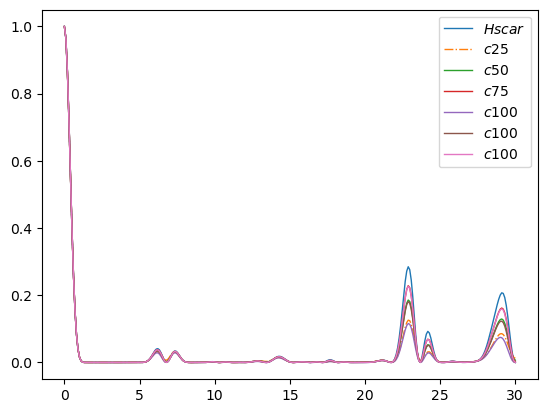

In [10]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, expect(psi1*psi1.dag(),evsc1.states),linewidth=1.0, label=r'$Hscar$')
axes.plot(tlist, expect(psi1*psi1.dag(),evL11.states),linewidth=1.0, linestyle='-.',label=r'$c25$')
axes.plot(tlist, expect(psi1*psi1.dag(),evL21.states),linewidth=1.0, label=r'$c50$')
axes.plot(tlist, expect(psi1*psi1.dag(),evL31.states),linewidth=1.0, label=r'$c75$')
axes.plot(tlist, expect(psi1*psi1.dag(),evLa11.states),linewidth=1.0, label=r'$c100$')
axes.plot(tlist, expect(psi1*psi1.dag(),evLa21.states),linewidth=1.0, label=r'$c100$')
axes.plot(tlist, expect(psi1*psi1.dag(),evLa31.states),linewidth=1.0, label=r'$c100$')
#plt.xlim(19,21)
#plt.ylim(0.3,0.8)
axes.legend(loc=1);

In [8]:
evsc2=mesolve(H, psi2, tlist,[], [])
evL12=mesolve(H0, psi2, tlist,Lind(50), [])
evL22=mesolve(H0, psi2, tlist,Lind(100), [])
evL32=mesolve(H0, psi2, tlist,Lind(200), [])
evLa12=mesolve(Hp, psi2, tlist,Linda(50), [])
evLa22=mesolve(Hp, psi2, tlist,Linda(100), [])
evLa32=mesolve(Hp, psi2, tlist,Linda(200), [])

In [11]:
#qsave(evsc2,'H_psi2')
#qsave(evL12,'L50_psi2')
#qsave(evL22,'L100_psi2')
#qsave(evL32,'L200_psi2')
#qsave(evLa12,'La50_psi2')
#qsave(evLa22,'La100_psi2')
qsave(evLa32,'La200_psi2')

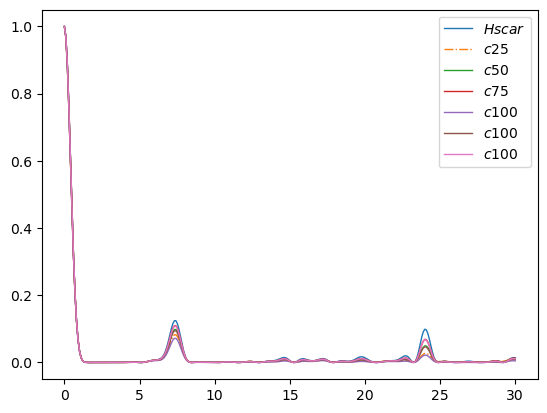

In [9]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, expect(psi2*psi2.dag(),evsc2.states),linewidth=1.0, label=r'$Hscar$')
axes.plot(tlist, expect(psi2*psi2.dag(),evL12.states),linewidth=1.0, linestyle='-.',label=r'$c25$')
axes.plot(tlist, expect(psi2*psi2.dag(),evL22.states),linewidth=1.0, label=r'$c50$')
axes.plot(tlist, expect(psi2*psi2.dag(),evL32.states),linewidth=1.0, label=r'$c75$')
axes.plot(tlist, expect(psi2*psi2.dag(),evLa12.states),linewidth=1.0, label=r'$c100$')
axes.plot(tlist, expect(psi2*psi2.dag(),evLa22.states),linewidth=1.0, label=r'$c100$')
axes.plot(tlist, expect(psi2*psi2.dag(),evLa32.states),linewidth=1.0, label=r'$c100$')
#plt.xlim(19,21)
#plt.ylim(0.3,0.8)
axes.legend(loc=1);

In [24]:
#标准耗散通道，调控c=b由小变大
evol01=mesolve(H, psi1, tlist,[], [])
evol11=mesolve(H0, psi1, tlist,Lind(25,25), [])
evol21=mesolve(H0, psi1, tlist,Lind(50,50), [])
evol31=mesolve(H0, psi1, tlist,Lind(75,75), [])
evol41=mesolve(H0, psi1, tlist,Lind(100,100), [])

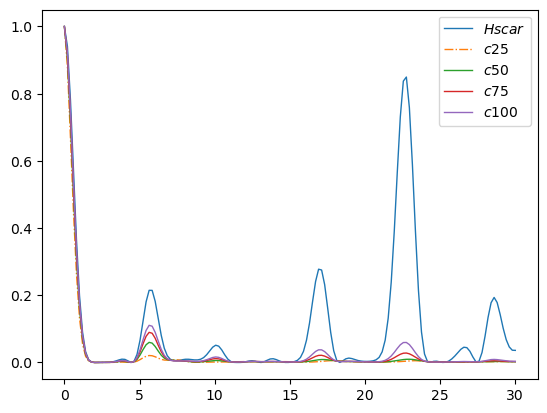

In [12]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, expect(psi1*psi1.dag(),evol01.states),linewidth=1.0, label=r'$Hscar$')
axes.plot(tlist, expect(psi1*psi1.dag(),evol11.states),linewidth=1.0, linestyle='-.',label=r'$c25$')
axes.plot(tlist, expect(psi1*psi1.dag(),evol21.states),linewidth=1.0, label=r'$c50$')
axes.plot(tlist, expect(psi1*psi1.dag(),evol31.states),linewidth=1.0, label=r'$c75$')
axes.plot(tlist, expect(psi1*psi1.dag(),evol41.states),linewidth=1.0, label=r'$c100$')
#plt.xlim(19,21)
#plt.ylim(0.3,0.8)
axes.legend(loc=1);

In [25]:
t=len(tlist)
ovH1=np.zeros(t)
ovH2=np.zeros(t)
ovH3=np.zeros(t)
ovH4=np.zeros(t)
ovH11=np.zeros(t)
ovH21=np.zeros(t)
ovH31=np.zeros(t)
ovH41=np.zeros(t)
for i in range(t):
    ovH1[i]=expect(evol1.states[i],evol0.states[i])
    ovH2[i]=expect(evol2.states[i],evol0.states[i])
    ovH3[i]=expect(evol3.states[i],evol0.states[i])
    ovH4[i]=expect(evol4.states[i],evol0.states[i])
    ovH11[i]=expect(evol11.states[i],evol01.states[i])
    ovH21[i]=expect(evol21.states[i],evol01.states[i])
    ovH31[i]=expect(evol31.states[i],evol01.states[i])
    ovH41[i]=expect(evol41.states[i],evol01.states[i])

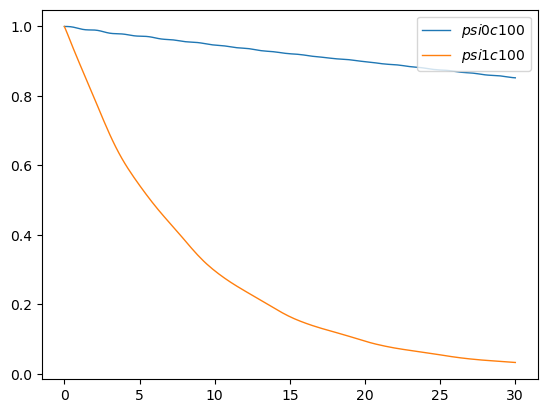

In [14]:
fig, axes = plt.subplots(1,1)

#axes.plot(tlist, ovH1,linewidth=1.0, label=r'$psi0c25$')
#axes.plot(tlist, ovH2,linewidth=1.0, linestyle='-.',label=r'$psi0c50$')
#axes.plot(tlist, ovH3,linewidth=1.0, label=r'$psi0c75$')
axes.plot(tlist, ovH4,linewidth=1.0, label=r'$psi0c100$')
#axes.plot(tlist, ovH11,linewidth=1.0, label=r'$psi1c25$')
#axes.plot(tlist, ovH21,linewidth=1.0, label=r'$psi1c50$')
#axes.plot(tlist, ovH31,linewidth=1.0, label=r'$psi1c75$')
axes.plot(tlist, ovH41,linewidth=1.0, label=r'$psi1c100$')
#plt.xlim(19,21)
#plt.ylim(0.3,0.8)
axes.legend(loc=1);

In [26]:
psi2=tensor(st1,st2,st1,st1,st1)
evol42=mesolve(H0, psi2, tlist,Lind(100,100), [])
evol02=mesolve(H, psi2, tlist,[], [])

In [27]:
ovH42=np.zeros(t)
for i in range(t):
    ovH42[i]=expect(evol42.states[i],evol02.states[i])

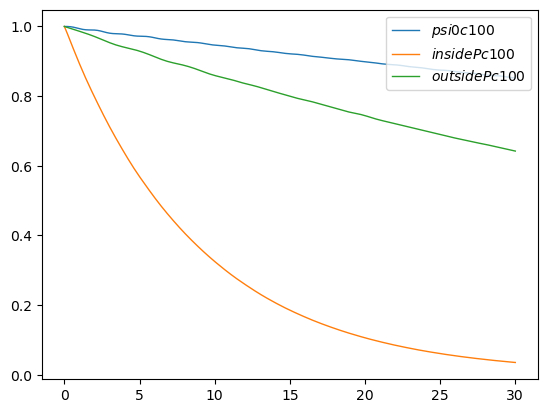

In [28]:
fig, axes = plt.subplots(1,1)

axes.plot(tlist, ovH4,linewidth=1.0, label=r'$psi0c100$')
axes.plot(tlist, ovH41,linewidth=1.0, label=r'$insidePc100$')
axes.plot(tlist, ovH42,linewidth=1.0, label=r'$outsidePc100$')
#plt.xlim(19,21)
#plt.ylim(0.3,0.8)
axes.legend(loc=1);